# Shared Evaluation Figures (RGB + MSI)

This notebook visualizes training dynamics from CSV files.

Expected inputs:
- `eval_results/rgb_loss_history.csv` for RGB with Cosine Annealing
- `eval_results/rgb_loss_history_no_cosine.csv` for RGB without Cosine Annealing
- `eval_results/msi_loss_history.csv`

Required CSV columns:
- `epoch`
- `train_loss`
- `val_loss`
- `val_acc`

Outputs:
- Combined loss figure with two panels:
  - RGB with Cosine Annealing: train loss + validation loss
  - MSI: train loss + validation loss
- RGB scheduler comparison figure:
  - RGB without Cosine Annealing
  - RGB with Cosine Annealing
- RGB validation accuracy comparison figure:
  - RGB without Cosine Annealing
  - RGB with Cosine Annealing
- Saved figures in `notebooks/figures/` for the report.

In [1]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
_CWD = Path.cwd().resolve()
PROJECT_ROOT = _CWD if (_CWD / "eval_results").exists() else _CWD.parent

EVAL_RESULTS_DIR = PROJECT_ROOT / "eval_results"
FIGURES_DIR = PROJECT_ROOT / "notebooks" / "figures"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

RGB_COSINE_CSV = EVAL_RESULTS_DIR / "rgb_loss_history.csv"
RGB_NO_COSINE_CSV = EVAL_RESULTS_DIR / "rgb_loss_history_no_cosine.csv"
MSI_CSV = EVAL_RESULTS_DIR / "msi_loss_history.csv"

print(f"Project root: {PROJECT_ROOT}")
print(f"RGB Cosine CSV: {RGB_COSINE_CSV}")
print(f"RGB no Cosine CSV: {RGB_NO_COSINE_CSV}")
print(f"MSI CSV: {MSI_CSV}")

Project root: /Users/david/eurosat
RGB Cosine CSV: /Users/david/eurosat/eval_results/rgb_loss_history.csv
RGB no Cosine CSV: /Users/david/eurosat/eval_results/rgb_loss_history_no_cosine.csv
MSI CSV: /Users/david/eurosat/eval_results/msi_loss_history.csv


In [3]:
rgb_cosine_df = pd.read_csv(RGB_COSINE_CSV)
rgb_no_cosine_df = pd.read_csv(RGB_NO_COSINE_CSV)
msi_df = pd.read_csv(MSI_CSV)

required_cols = {"epoch", "train_loss", "val_loss", "val_acc"}
assert required_cols.issubset(rgb_cosine_df.columns), f"RGB Cosine CSV missing columns: {required_cols - set(rgb_cosine_df.columns)}"
assert required_cols.issubset(rgb_no_cosine_df.columns), f"RGB no Cosine CSV missing columns: {required_cols - set(rgb_no_cosine_df.columns)}"
assert required_cols.issubset(msi_df.columns), f"MSI CSV missing columns: {required_cols - set(msi_df.columns)}"

rgb_cosine_df = rgb_cosine_df.sort_values("epoch").reset_index(drop=True)
rgb_no_cosine_df = rgb_no_cosine_df.sort_values("epoch").reset_index(drop=True)
msi_df = msi_df.sort_values("epoch").reset_index(drop=True)

rgb_cosine_df.head(), rgb_no_cosine_df.head(), msi_df.head()

(   epoch  train_loss  val_loss   val_acc
 0      1    1.278336  1.052344  0.613148
 1      2    0.852881  1.009239  0.629444
 2      3    0.656380  0.577201  0.796481
 3      4    0.507068  1.417023  0.675185
 4      5    0.424759  1.446033  0.568889,
    epoch  train_loss  val_loss   val_acc
 0      1    1.278336  1.052344  0.613148
 1      2    0.858571  1.035430  0.610000
 2      3    0.656868  0.980716  0.745000
 3      4    0.523556  1.750591  0.654259
 4      5    0.438592  1.237775  0.678704,
    epoch  train_loss  val_loss   val_acc
 0      1    1.016144  1.328128  0.597778
 1      2    0.570294  1.621468  0.609630
 2      3    0.445332  0.388902  0.869815
 3      4    0.351085  0.558827  0.828704
 4      5    0.298079  0.286675  0.902037)

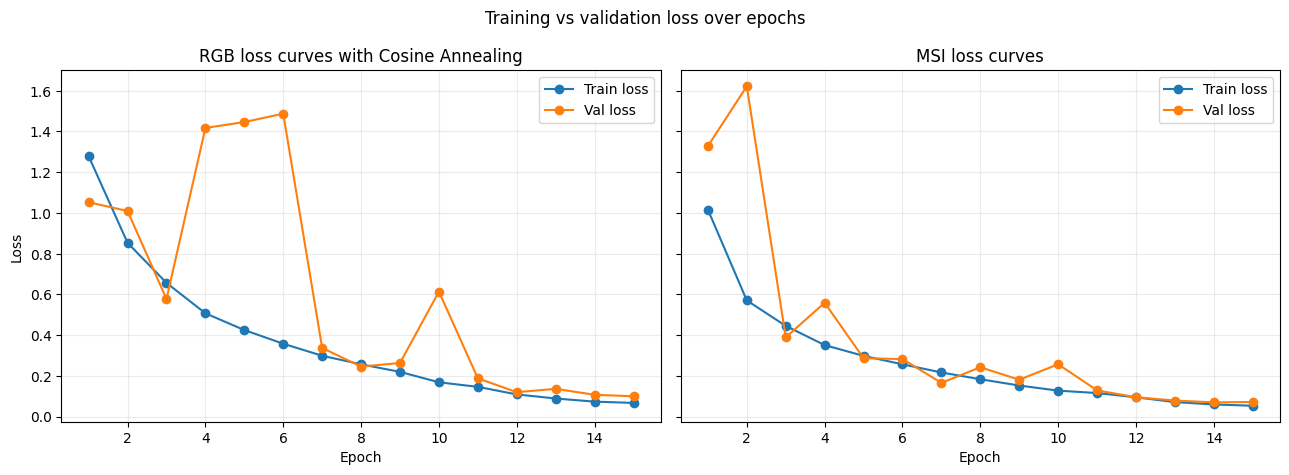

Saved: /Users/david/eurosat/notebooks/figures/rgb_msi_loss_curves.png


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.8), sharey=True)

axes[0].plot(rgb_cosine_df["epoch"], rgb_cosine_df["train_loss"], marker="o", label="Train loss")
axes[0].plot(rgb_cosine_df["epoch"], rgb_cosine_df["val_loss"], marker="o", label="Val loss")
axes[0].set_title("RGB loss curves with Cosine Annealing")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].grid(alpha=0.25)
axes[0].legend()

axes[1].plot(msi_df["epoch"], msi_df["train_loss"], marker="o", label="Train loss")
axes[1].plot(msi_df["epoch"], msi_df["val_loss"], marker="o", label="Val loss")
axes[1].set_title("MSI loss curves")
axes[1].set_xlabel("Epoch")
axes[1].grid(alpha=0.25)
axes[1].legend()

fig.suptitle("Training vs validation loss over epochs")
fig.tight_layout()

output_png = FIGURES_DIR / "rgb_msi_loss_curves.png"
fig.savefig(output_png, dpi=300, bbox_inches="tight")
plt.show()

print(f"Saved: {output_png}")

## RGB Scheduler Comparison

The first RGB run uses a fixed learning rate. The second run uses Cosine Annealing with the same seed, batch size, learning rate, and 15 epochs.

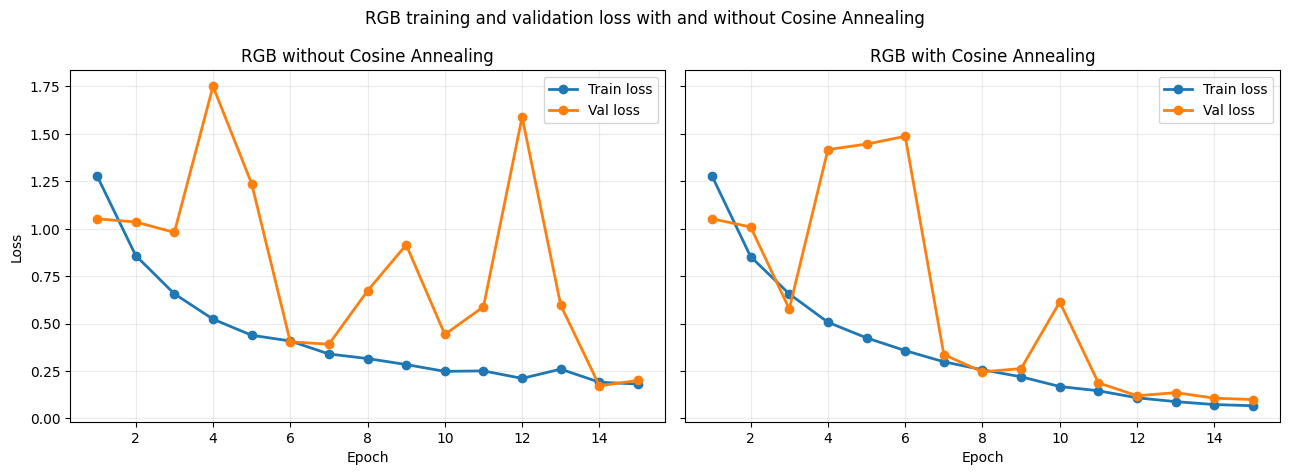

Saved: /Users/david/eurosat/notebooks/figures/rgb_cosine_annealing_loss_curves.png


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.8), sharey=True)

runs = [
    (axes[0], rgb_no_cosine_df, "RGB without Cosine Annealing"),
    (axes[1], rgb_cosine_df, "RGB with Cosine Annealing"),
]

for ax, df, title in runs:
    ax.plot(df["epoch"], df["train_loss"], marker="o", linewidth=2, label="Train loss")
    ax.plot(df["epoch"], df["val_loss"], marker="o", linewidth=2, label="Val loss")
    ax.set_title(title)
    ax.set_xlabel("Epoch")
    ax.grid(alpha=0.25)
    ax.legend()

axes[0].set_ylabel("Loss")
fig.suptitle("RGB training and validation loss with and without Cosine Annealing")
fig.tight_layout()

output_png = FIGURES_DIR / "rgb_cosine_annealing_loss_curves.png"
fig.savefig(output_png, dpi=300, bbox_inches="tight")
plt.show()

print(f"Saved: {output_png}")

## RGB Validation Accuracy Comparison

This uses the same two RGB runs to compare validation accuracy across epochs.

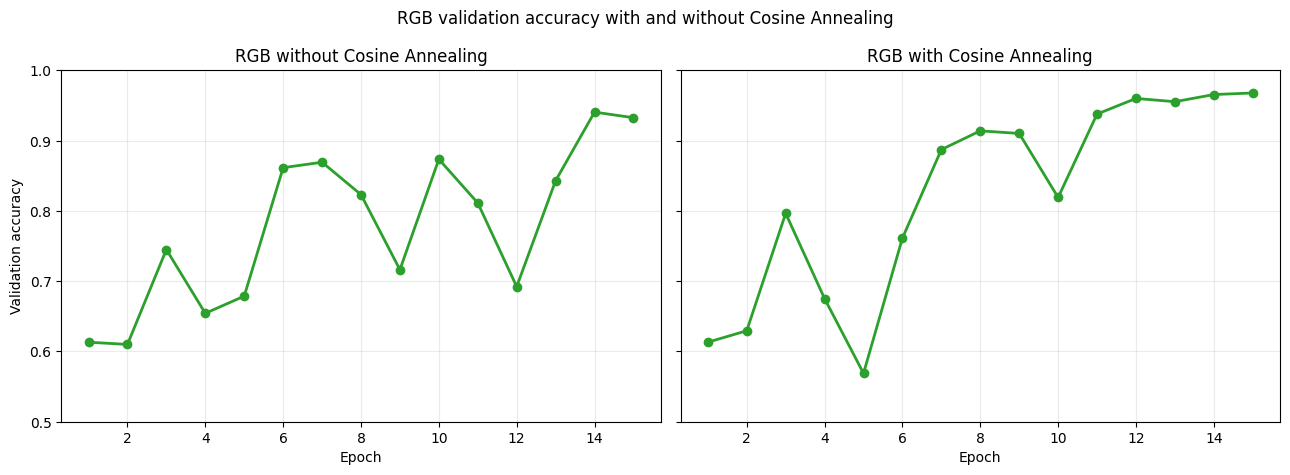

Saved: /Users/david/eurosat/notebooks/figures/rgb_cosine_annealing_val_accuracy.png


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.8), sharey=True)

runs = [
    (axes[0], rgb_no_cosine_df, "RGB without Cosine Annealing"),
    (axes[1], rgb_cosine_df, "RGB with Cosine Annealing"),
]

for ax, df, title in runs:
    ax.plot(df["epoch"], df["val_acc"], marker="o", linewidth=2, color="tab:green")
    ax.set_title(title)
    ax.set_xlabel("Epoch")
    ax.set_ylim(0.5, 1.0)
    ax.grid(alpha=0.25)

axes[0].set_ylabel("Validation accuracy")
fig.suptitle("RGB validation accuracy with and without Cosine Annealing")
fig.tight_layout()

output_png = FIGURES_DIR / "rgb_cosine_annealing_val_accuracy.png"
fig.savefig(output_png, dpi=300, bbox_inches="tight")
plt.show()

print(f"Saved: {output_png}")